**Trabajo Final de Redes Neuronales**

**Maestría en Ciencias de la Inteligencia Artificial**

*Facultad de Ingeniería – Universidad Nacional de Asunción*

Profesor: *MSc. Ing. Enrique Paiva*

Alumna: Ing. Malena Russo

# 1. Problema y Motivación

## 1.1 Definición del problema

Predecir la bioactividad de fármacos frente a múltiples virus utilizando representaciones moleculares y modelos de redes neuronales.

## 1.2 Tipo de problema

Es un:

**Problema de clasificación multi-output**

- Cada virus representa una salida binaria

- Se predice si una droga es activa o no frente a cada virus

## 1.3 Descripción del dataset

El dataset proviene de:

- DrugVirus

- Drug Repurposing Hub

- Representaciones moleculares (MACCS en este caso)

Características:

X: fingerprint molecular ( MACCS con 166 features)

Y: matriz binaria droga-virus

- 6801 drogas

- 89 virus


## 1.4 Relevancia del problema

El descubrimiento de antivirales de amplio espectro es un desafío crítico en salud pública. El uso de modelos de inteligencia artificial permite priorizar candidatos farmacológicos reduciendo tiempo y costos experimentales, lo cual es especialmente relevante ante emergencias sanitarias.

# 2. Datos y preprocesamiento

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
path = "/content/drive/MyDrive/Colab Notebooks/Redes Neuronales/Entrega Final"
print(os.listdir(path))

['Y_final_schemnet.npy', 'X_MACCS.npy', 'Entrega_Final_Redes Neuronales.ipynb']


In [ ]:
import numpy as np

X = np.load(path + "/X_MACCS.npy")
Y = np.load(path + "/Y_final_schemnet.npy")

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (6801, 166)
Y shape: (6801, 89)




## 2.1 Número de observaciones y variables


La matriz de entrada \(X\) tiene dimensión:

$$
X \in \mathbb{R}^{n \times d}
$$

donde:

- \(n\) representa el número de observaciones (drogas).
- \(d\) representa el número de variables o características moleculares.

Cada observación corresponde a una droga, representada mediante un fingerprint molecular binario (por ejemplo, MACCS), compuesto por 166 variables binarias.

En forma matricial:

- \( X \) tiene dimensión: `(6801, 166)`

La matriz de salida \(Y\) corresponde a una estructura multi-output:

$$
Y \in \mathbb{R}^{n \times m}
$$

donde:

- \(m\) representa el número de virus considerados.

Cada columna de \( Y \) indica si una droga es activa (1) o no activa (0) frente a un virus específico.

En forma matricial:

- \( Y \) tiene dimensión: `(6801, 89)`

Por lo tanto, el problema corresponde a una **clasificación binaria multi-output**, donde el modelo debe predecir simultáneamente la actividad de cada droga frente a múltiples virus.

## 2.2 Esquema de evaluación (LOOCV tipo ranking)


- Se selecciona un virus objetivo \(W\).
- Se aplica **LOOCV sobre las instancias positivas** del virus \(W\) (drogas activas contra \(W\)). Este virus W es elegido de forma aleatoria.
- En cada iteración se deja **1 positivo fuera** (test) y se construye un conjunto de evaluación con:
  - 1 instancia positiva (la dejada fuera)
  - 3999 instancias negativas muestreadas aleatoriamente
- El modelo se entrena con el resto de las observaciones (excluyendo las 4000 del set de test) y se evalúa como un **problema de ranking**, midiendo la posición (rank) del positivo entre los 4000 candidatos.

Este procedimiento permite evaluar la capacidad del modelo de priorizar correctamente una droga activa entre múltiples candidatos no activos.

In [ ]:
#busqueda de virus W de manera aleatoria y reproducible

import numpy as np

rng = np.random.default_rng(42)

# Elegir columna al azar
W = int(rng.integers(0, Y.shape[1]))

print("Virus W elegido:", W)
print("Cantidad de virus totales:", Y.shape[1])
print("Positivos en W:", int(Y[:, W].sum()))

Virus W elegido: 7
Cantidad de virus totales: 89
Positivos en W: 45


In [ ]:
#Construccion del split

import numpy as np

def prepare_split(X, Y, W, idx_ones, idx_zeros, j=0, n_test=4000, seed=42):
    """
    Split para un virus W:
    - deja fuera 1 positivo (idx_ones[j]) y lo mete en test
    - samplea (n_test-1) negativos y los mete en test
    - train = todo lo demás
    Devuelve: x_train, y_train, x_test, y_test, pos_in_test
    """
    rng = np.random.default_rng(seed + j)

    # 1) positivo dejado fuera
    pos_out = int(idx_ones[j])

    # 2) sample de negativos para test
    n_neg_test = n_test - 1
    neg_test = rng.choice(idx_zeros, size=n_neg_test, replace=False)

    # 3) índices de test (positivo primero)
    test_idx = np.concatenate([[pos_out], neg_test])

    # 4) train = todo menos test
    all_idx = np.arange(X.shape[0])
    train_idx = np.setdiff1d(all_idx, test_idx, assume_unique=False)

    x_train = X[train_idx]
    y_train = Y[train_idx, W].astype(int)

    x_test = X[test_idx]
    y_test = Y[test_idx, W].astype(int)

    pos_in_test = 0  # como pusimos el positivo primero
    return x_train, y_train, x_test, y_test, pos_in_test


In [ ]:
#LOOCV
def loocv_for_W(X, Y, W, model_ctor, seed=42):
    idx_ones  = np.where(Y[:, W] == 1)[0]
    idx_zeros = np.where(Y[:, W] == 0)[0]

    ranks = []
    for j in range(len(idx_ones)):
        x_train, y_train, x_test, y_test, pos_in_test = prepare_split(
            X, Y, W, idx_ones, idx_zeros, j=j, seed=seed
        )

        model = model_ctor()
        model.fit(x_train, y_train)

        # scores para ranking
        if hasattr(model, "predict_proba"):
            scores = model.predict_proba(x_test)[:, 1]
        else:
            scores = model.decision_function(x_test)

        ranks.append(rank_of_positive(scores, pos_in_test))

    ranks = np.array(ranks)
    return {
        "W": W,
        "k_pos": len(idx_ones),
        "ranks": ranks,
        "mean_rank": float(ranks.mean()),
        "median_rank": float(np.median(ranks)),
        "min_rank": int(ranks.min()),
        "max_rank": int(ranks.max())
    }

In [ ]:
def rank_of_positive(scores, pos_in_test=0):
    pos_score = scores[pos_in_test]
    return 1 + int(np.sum(scores > pos_score))  # rank 1 = mejor

## 2.3 Valores faltantes y outliers

- Las representaciones tipo fingerprint utilizadas (MACCS) son vectores binarios, por lo que no se detectaron valores faltantes.
- No se aplicó tratamiento de outliers, ya que las variables de entrada son binarias (0/1) y no corresponden a mediciones continuas susceptibles a valores extremos.

## 2.4 Escalamiento y encoding

- No se requirió encoding adicional ya que los fingerprints ya están en formato numérico.
- No se aplicó escalamiento (normalización/estandarización), dado que las variables de entrada corresponden a fingerprints binarios (0/1).

# 3. Modelo Ulizado

## 3.1 Modelos probados

MLP implementada en PyTorch (modelo final), para controlar entrenamiento, regularización y ponderación de clase.


In [ ]:
#Metricas de ranking
def ranking_metrics(ranks):
    ranks = np.array(ranks)
    return {
        "MeanRank": ranks.mean(),
        "MedianRank": np.median(ranks),
        "MRR": np.mean(1.0 / ranks),
        "Hit@10": np.mean(ranks <= 10),
        "Hit@50": np.mean(ranks <= 50),
        "Hit@100": np.mean(ranks <= 100),
    }

In [ ]:
import numpy as np
import torch
import torch.nn as nn

class TorchMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)  # logits
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

class TorchMLPWrapper:
    def __init__(self, in_dim, lr=1e-3, epochs=25, batch_size=256, pos_weight=100.0, weight_decay=1e-4, seed=42):
        self.in_dim = in_dim
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.pos_weight = float(pos_weight)
        self.weight_decay = weight_decay # Add weight_decay here
        self.seed = seed
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model = TorchMLP(in_dim).to(self.device)

    def fit(self, X, y):
        torch.manual_seed(self.seed)
        np.random.seed(self.seed)

        X = torch.tensor(X, dtype=torch.float32, device=self.device)
        y = torch.tensor(y, dtype=torch.float32, device=self.device)

        loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(self.pos_weight, device=self.device))
        opt = torch.optim.Adam(self.model.parameters(), lr=self.lr, weight_decay=self.weight_decay) # Use self.weight_decay

        n = X.shape[0]
        for _ in range(self.epochs):
            perm = torch.randperm(n, device=self.device)
            for i in range(0, n, self.batch_size):
                idx = perm[i:i+self.batch_size]
                xb, yb = X[idx], y[idx]
                opt.zero_grad()
                logits = self.model(xb);
                loss = loss_fn(logits, yb)
                loss.backward()
                opt.step()
        return self

    def predict_proba(self, X):
        X = torch.tensor(X, dtype=torch.float32, device=self.device)
        with torch.no_grad():
            logits = self.model(X)
            probs = torch.sigmoid(logits).detach().cpu().numpy()
        return np.vstack([1 - probs, probs]).T

In [ ]:
def Torch_model_wd(pw):
    return lambda: TorchMLPWrapper(
        in_dim=X.shape[1],
        lr=1e-3,
        epochs=25,
        batch_size=256,
        pos_weight=pw,
        seed=42
    )

for pw in [23, 24, 25, 26]:
    out = loocv_for_W(X, Y, W, Torch_model_wd(pw), seed=42)
    m = ranking_metrics(out["ranks"])
    print("pw =", pw, "MeanRank:", float(m["MeanRank"]), "MRR:", float(m["MRR"]))

pw = 23 MeanRank: 968.0444444444445 MRR: 0.03752624668915749
pw = 24 MeanRank: 987.1111111111111 MRR: 0.03610239342339733
pw = 25 MeanRank: 979.0444444444445 MRR: 0.026570798517248854
pw = 26 MeanRank: 955.8222222222222 MRR: 0.03173013639824439


### 3.1.1 Tuning

In [ ]:
import pandas as pd

def Torch_model(pw, wd):
    return lambda: TorchMLPWrapper(
        in_dim=X.shape[1],
        lr=1e-3,
        epochs=25,
        batch_size=256,
        pos_weight=pw,
        weight_decay=wd,
        seed=42
    )

pos_weights = [26, 27, 28]
weight_decays = [0.0, 1e-5, 1e-4, 1e-3]

rows = []
best = None

for pw in pos_weights:
    for wd in weight_decays:
        out = loocv_for_W(X, Y, W, Torch_model(pw, wd), seed=42)
        m = ranking_metrics(out["ranks"])
        row = {
            "pos_weight": pw,
            "weight_decay": wd,
            "MeanRank": float(m["MeanRank"]),
            "MedianRank": float(m["MedianRank"]),
            "MRR": float(m["MRR"]),
            "Hit@10": float(m["Hit@10"]),
            "Hit@50": float(m["Hit@50"]),
            "Hit@100": float(m["Hit@100"]),
        }
        rows.append(row)
        if best is None or row["MeanRank"] < best["MeanRank"]:
            best = row

df_tuning = pd.DataFrame(rows).sort_values("MeanRank")
df_tuning, best

(    pos_weight  weight_decay    MeanRank  MedianRank       MRR    Hit@10  \
 3           26       0.00100  944.511111       298.0  0.023720  0.066667   
 7           27       0.00100  946.488889       281.0  0.037570  0.044444   
 6           27       0.00010  953.177778       411.0  0.041642  0.044444   
 11          28       0.00100  954.444444       258.0  0.018411  0.044444   
 10          28       0.00010  954.933333       381.0  0.019529  0.044444   
 2           26       0.00010  955.822222       342.0  0.031730  0.044444   
 1           26       0.00001  962.000000       472.0  0.023770  0.066667   
 9           28       0.00001  965.222222       342.0  0.024191  0.044444   
 5           27       0.00001  971.044444       350.0  0.026392  0.044444   
 4           27       0.00000  972.244444       372.0  0.025301  0.066667   
 8           28       0.00000  977.577778       423.0  0.042216  0.044444   
 0           26       0.00000  980.666667       339.0  0.044413  0.066667   

In [ ]:
df_tuning.to_csv("tuning_liviano_torch_mlp_W7_seed42.csv", index=False)

In [ ]:
import pandas as pd

def Torch_model(pw, wd):
    return lambda: TorchMLPWrapper(
        in_dim=X.shape[1],
        lr=1e-3,
        epochs=25,
        batch_size=256,
        pos_weight=pw,
        weight_decay=wd,
        seed=42
    )

pos_weights = [25, 26, 27]
weight_decays = [5e-4, 7e-4, 1e-3, 1.5e-3, 2e-3, 3e-3]

rows = []
best = None

for pw in pos_weights:
    for wd in weight_decays:
        out = loocv_for_W(X, Y, W, Torch_model(pw, wd), seed=42)
        m = ranking_metrics(out["ranks"])
        row = {
            "pos_weight": pw,
            "weight_decay": wd,
            "MeanRank": float(m["MeanRank"]),
            "MedianRank": float(m["MedianRank"]),
            "MRR": float(m["MRR"]),
            "Hit@10": float(m["Hit@10"]),
            "Hit@50": float(m["Hit@50"]),
            "Hit@100": float(m["Hit@100"]),
        }
        rows.append(row)
        if best is None or row["MeanRank"] < best["MeanRank"]:
            best = row
        print("pw", pw, "wd", wd, "-> MeanRank", row["MeanRank"], "MRR", row["MRR"])

df_fine = pd.DataFrame(rows).sort_values("MeanRank")
df_fine.head(10), best

pw 25 wd 0.0005 -> MeanRank 972.2666666666667 MRR 0.04020143157198941
pw 25 wd 0.0007 -> MeanRank 952.3111111111111 MRR 0.03865889488919118
pw 25 wd 0.001 -> MeanRank 931.9333333333333 MRR 0.036080480370933615
pw 25 wd 0.0015 -> MeanRank 955.1333333333333 MRR 0.03462138982847014
pw 25 wd 0.002 -> MeanRank 908.0444444444445 MRR 0.020345781906728325
pw 25 wd 0.003 -> MeanRank 905.7555555555556 MRR 0.03404690128827683
pw 26 wd 0.0005 -> MeanRank 954.3333333333334 MRR 0.024572974746554548
pw 26 wd 0.0007 -> MeanRank 944.1777777777778 MRR 0.03974702285861887
pw 26 wd 0.001 -> MeanRank 944.5111111111111 MRR 0.023719549425821107
pw 26 wd 0.0015 -> MeanRank 944.9111111111112 MRR 0.031591126373007795
pw 26 wd 0.002 -> MeanRank 907.6666666666666 MRR 0.028833302570782995
pw 26 wd 0.003 -> MeanRank 893.8 MRR 0.04605477705781136
pw 27 wd 0.0005 -> MeanRank 981.4222222222222 MRR 0.029429485244234884
pw 27 wd 0.0007 -> MeanRank 970.5555555555555 MRR 0.03930796278156006
pw 27 wd 0.001 -> MeanRank 946.

(    pos_weight  weight_decay    MeanRank  MedianRank       MRR    Hit@10  \
 17          27        0.0030  892.022222       266.0  0.045909  0.066667   
 11          26        0.0030  893.800000       303.0  0.046055  0.066667   
 5           25        0.0030  905.755556       340.0  0.034047  0.044444   
 10          26        0.0020  907.666667       309.0  0.028833  0.044444   
 4           25        0.0020  908.044444       311.0  0.020346  0.022222   
 16          27        0.0020  920.955556       379.0  0.025977  0.044444   
 2           25        0.0010  931.933333       311.0  0.036080  0.044444   
 15          27        0.0015  940.666667       333.0  0.033035  0.044444   
 7           26        0.0007  944.177778       296.0  0.039747  0.066667   
 8           26        0.0010  944.511111       298.0  0.023720  0.066667   
 
       Hit@50   Hit@100  
 17  0.222222  0.311111  
 11  0.222222  0.311111  
 5   0.222222  0.266667  
 10  0.200000  0.288889  
 4   0.244444  0.3111

In [ ]:
#micro alrededor de wd=0.003

for wd in [0.0025, 0.003, 0.0035, 0.004, 0.005]:
    out = loocv_for_W(X, Y, W,
                      lambda: TorchMLPWrapper(
                          in_dim=X.shape[1],
                          lr=1e-3,
                          epochs=25,
                          batch_size=256,
                          pos_weight=27,
                          weight_decay=wd,
                          seed=42),
                      seed=42)
    m = ranking_metrics(out["ranks"])
    print("wd =", wd, "MeanRank:", float(m["MeanRank"]), "MRR:", float(m["MRR"]))

wd = 0.0025 MeanRank: 905.8888888888889 MRR: 0.03546270693169013
wd = 0.003 MeanRank: 892.0222222222222 MRR: 0.04590905642467107
wd = 0.0035 MeanRank: 865.1111111111111 MRR: 0.023431935854580796
wd = 0.004 MeanRank: 893.7111111111111 MRR: 0.02293338715858476
wd = 0.005 MeanRank: 882.1111111111111 MRR: 0.03855120419740361


In [ ]:
best_cfg = {"pos_weight": 27, "weight_decay": 0.0035, "lr": 1e-3, "epochs": 25, "batch_size": 256}
best_cfg

{'pos_weight': 27,
 'weight_decay': 0.0035,
 'lr': 0.001,
 'epochs': 25,
 'batch_size': 256}

In [ ]:
out_best = loocv_for_W(
    X, Y, W,
    lambda: TorchMLPWrapper(
        in_dim=X.shape[1],
        lr=1e-3,
        epochs=25,
        batch_size=256,
        pos_weight=27,
        weight_decay=0.0035,
        seed=42
    ),
    seed=42
)

ranking_metrics(out_best["ranks"])

{'MeanRank': np.float64(865.1111111111111),
 'MedianRank': np.float64(260.0),
 'MRR': np.float64(0.023431935854580796),
 'Hit@10': np.float64(0.044444444444444446),
 'Hit@50': np.float64(0.2222222222222222),
 'Hit@100': np.float64(0.3111111111111111)}

In [ ]:
metrics_best = ranking_metrics(out_best["ranks"])
metrics_best

{'MeanRank': np.float64(865.1111111111111),
 'MedianRank': np.float64(260.0),
 'MRR': np.float64(0.023431935854580796),
 'Hit@10': np.float64(0.044444444444444446),
 'Hit@50': np.float64(0.2222222222222222),
 'Hit@100': np.float64(0.3111111111111111)}

## 3.2 Justificación de la elección
Se eligió implementar la red neuronal en PyTorch debido al fuerte desbalance del problema (1 positivo vs 3999 negativos en cada fold), lo cual hace que un MLP estándar tienda a ignorar la clase positiva.  
PyTorch permite incorporar:
- Ponderación de clase (`pos_weight`) en la pérdida.
- Regularización L2 (`weight_decay`) en el optimizador.
- Control explícito del entrenamiento (epochs, batch_size, etc.).

## 3.3 Parámetros importantes
Parámetros clave del modelo final:
- `pos_weight`: ponderación de la clase positiva en la pérdida.
- `weight_decay`: regularización L2 aplicada en Adam.
- `learning_rate`, `epochs`, `batch_size`: control del proceso de entrenamiento.

Configuración final seleccionada:
- `pos_weight = 27`
- `weight_decay = 0.0035`
- `lr = 1e-3`
- `epochs = 25`
- `batch_size = 256`


## 3.4 Métrica utilizada para evaluación
Se utilizó LOOCV tipo ranking:
- En cada fold se evalúa un set de 4000 candidatos (1 positivo + 3999 negativos).
- Se calcula el ranking del positivo en base al score del modelo.

Métrica principal:
- **MeanRank** (menor es mejor)

Métricas complementarias:
- MedianRank, MRR, Hit@10, Hit@50, Hit@100

# 4. Resultados

## 4.1 Visualización y análisis de la curva de aprendizaje.

In [ ]:
np.save("ranks_final.npy", out_best["ranks"])

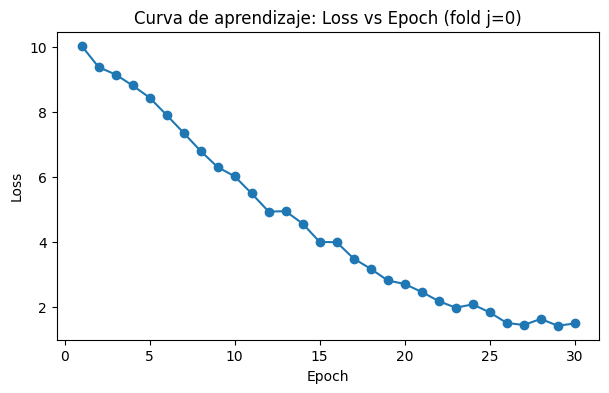

In [ ]:
import matplotlib.pyplot as plt

# Entrenar 1 vez en un fold (usamos el fold j=0 solo para curva)
idx_ones  = np.where(Y[:, W] == 1)[0]
idx_zeros = np.where(Y[:, W] == 0)[0]

x_train, y_train, x_test, y_test, pos_in_test = prepare_split(
    X, Y, W, idx_ones, idx_zeros, j=0, seed=42
)

# Creamos un wrapper que guarde loss_history
class TorchMLPWrapperWithHistory(TorchMLPWrapper):
    def fit(self, X, y):
        self.loss_history = []
        X = torch.tensor(X, dtype=torch.float32, device=self.device)
        y = torch.tensor(y, dtype=torch.float32, device=self.device)

        loss_fn = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor(self.pos_weight, device=self.device)
        )
        opt = torch.optim.Adam(
            self.model.parameters(), lr=self.lr, weight_decay=self.weight_decay
        )

        n = X.shape[0]
        for _ in range(self.epochs):
            perm = torch.randperm(n, device=self.device)
            epoch_loss = 0.0
            for i in range(0, n, self.batch_size):
                idx = perm[i:i+self.batch_size]
                xb, yb = X[idx], y[idx]
                opt.zero_grad()
                logits = self.model(xb)
                loss = loss_fn(logits, yb)
                loss.backward()
                opt.step()
                epoch_loss += loss.item()
            self.loss_history.append(epoch_loss)
        return self

model_curve = TorchMLPWrapperWithHistory(
    in_dim=X.shape[1],
    lr=1e-3,
    epochs=30,
    batch_size=256,
    pos_weight=27,
    weight_decay=0.0035,
    seed=42
)
model_curve.fit(x_train, y_train)

plt.figure(figsize=(7,4))
plt.plot(range(1, len(model_curve.loss_history)+1), model_curve.loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curva de aprendizaje: Loss vs Epoch (fold j=0)")
plt.show()

La curva de aprendizaje muestra la evolución de la función de pérdida (loss) durante el entrenamiento de la red neuronal a lo largo de las épocas.

En el gráfico se observa que la pérdida disminuye progresivamente a medida que aumenta el número de épocas, lo que indica que el modelo está aprendiendo a ajustar sus parámetros para reducir el error en los datos de entrenamiento.

Durante las primeras épocas se observa una reducción más pronunciada de la pérdida, lo cual es esperable ya que el modelo comienza a capturar los patrones principales del dataset. Posteriormente la disminución de la pérdida se vuelve más gradual, lo que indica que el modelo se aproxima a la convergencia.

No se observan oscilaciones fuertes ni aumentos abruptos de la pérdida, lo que sugiere que el proceso de entrenamiento es estable.

En general, la curva muestra un comportamiento adecuado de aprendizaje para la red neuronal utilizada en este experimento.

## 4.2 Gráficos y tablas del modelo final.

In [ ]:
import pandas as pd

results_df = pd.DataFrame([metrics_best])
results_df

,MeanRank,MedianRank,MRR,Hit@10,Hit@50,Hit@100
0,865.111111,260.0,0.023432,0.044444,0.222222,0.311111


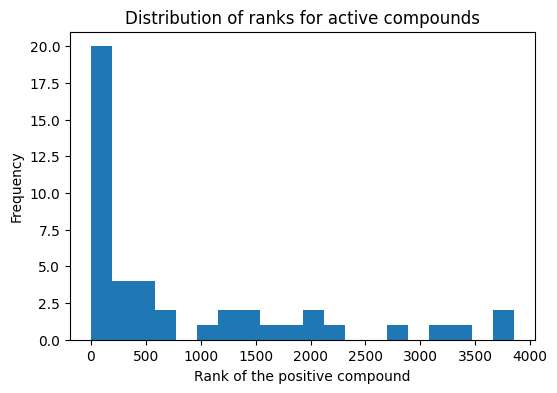

In [ ]:
import matplotlib.pyplot as plt

ranks = out_best["ranks"]

plt.figure(figsize=(6,4))
plt.hist(ranks, bins=20)

plt.xlabel("Rank of the positive compound")
plt.ylabel("Frequency")
plt.title("Distribution of ranks for active compounds")

plt.show()

# 5. Conclusiones y Aprendizajes

## Principales aprendizajes

En este trabajo se implementó una red neuronal para predecir la actividad antiviral de compuestos químicos utilizando fingerprints moleculares como variables de entrada. Se aplicó un esquema de evaluación LOOCV (Leave-One-Out Cross Validation) sobre un virus seleccionado aleatoriamente, lo que permitió evaluar la capacidad del modelo para priorizar compuestos activos frente a un gran número de compuestos inactivos.

Durante el proceso se exploraron distintos hiperparámetros del modelo, incluyendo el peso de la clase positiva (pos_weight) y el parámetro de regularización (weight_decay). El ajuste de estos hiperparámetros permitió mejorar el desempeño del modelo, obteniendo un MeanRank cercano a 865 para los compuestos activos.

Los resultados muestran que el modelo logra posicionar una fracción de los compuestos activos en las primeras posiciones del ranking, lo cual indica que la red neuronal es capaz de capturar parcialmente la relación entre las características moleculares y la actividad antiviral.

---

## Análisis de overfitting

A partir de la curva de aprendizaje se observa que la función de pérdida disminuye de forma progresiva durante el entrenamiento, sin presentar oscilaciones abruptas ni incrementos en las últimas épocas. Esto sugiere que el modelo converge de manera estable y no muestra señales claras de sobreajuste en el proceso de entrenamiento.

Además, el uso de regularización mediante el parámetro weight_decay contribuye a reducir el riesgo de overfitting.

---

## Limitaciones del dataset

Una de las principales limitaciones del dataset es el fuerte desbalance entre compuestos activos e inactivos. En este tipo de problemas de descubrimiento de fármacos, el número de compuestos activos suele ser muy pequeño en comparación con los inactivos, lo que dificulta el aprendizaje del modelo.

Asimismo, la información disponible se limita a fingerprints moleculares, que si bien capturan ciertas propiedades estructurales de las moléculas, pueden no contener toda la información necesaria para predecir la actividad antiviral con alta precisión.

---

## Qué se podría mejorar con más tiempo

Con más tiempo de desarrollo se podrían explorar arquitecturas de redes neuronales más complejas o modelos basados en grafos moleculares, los cuales han demostrado buenos resultados en problemas de química computacional.

También sería interesante evaluar el modelo utilizando distintos tipos de fingerprints moleculares o combinar múltiples representaciones químicas para mejorar la capacidad predictiva.

Finalmente, se podría ampliar el análisis comparando el desempeño de la red neuronal con otros modelos de aprendizaje automático, como Random Forest o Gradient Boosting, para analizar cuál enfoque resulta más adecuado para este tipo de problema.